In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

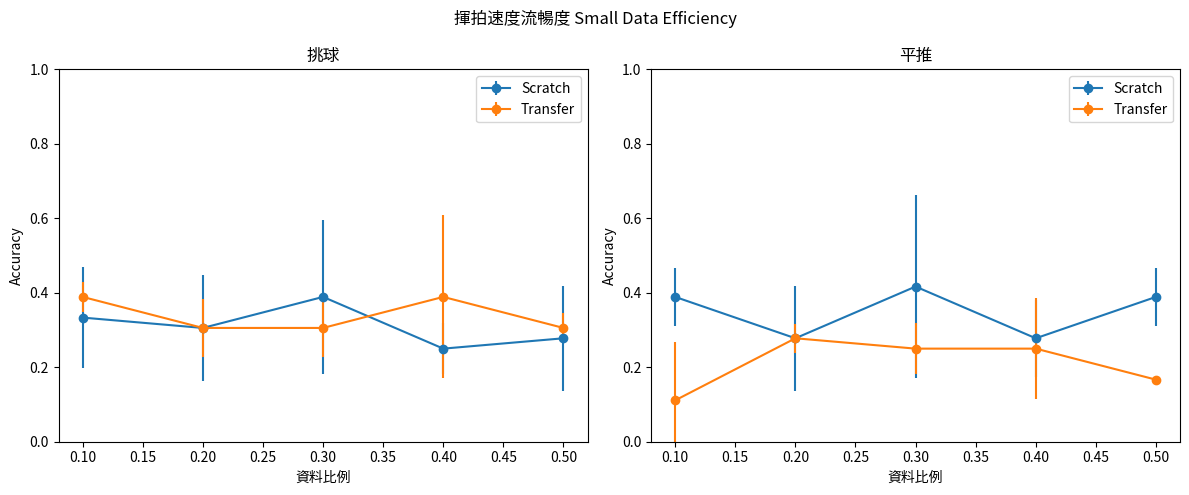

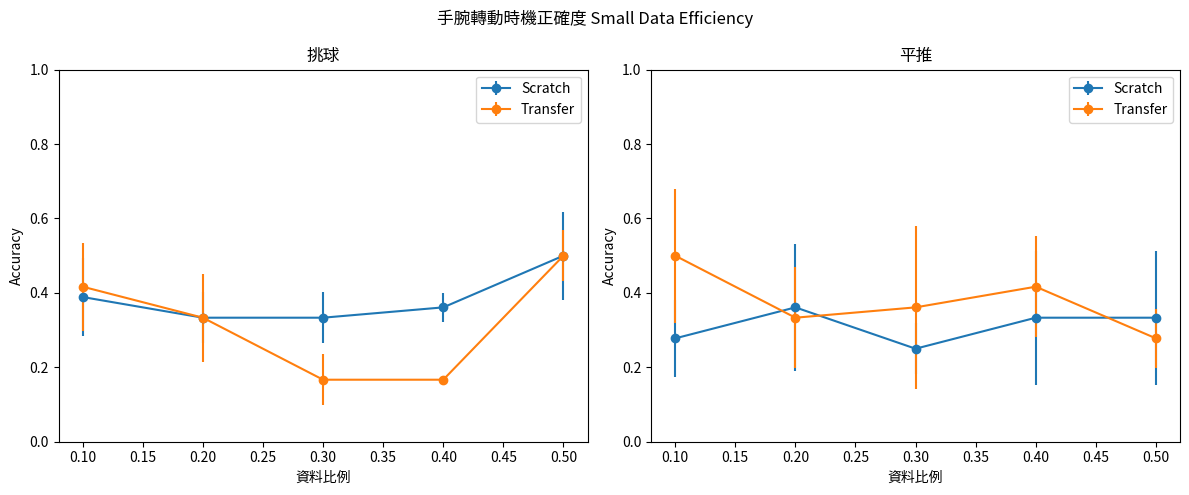

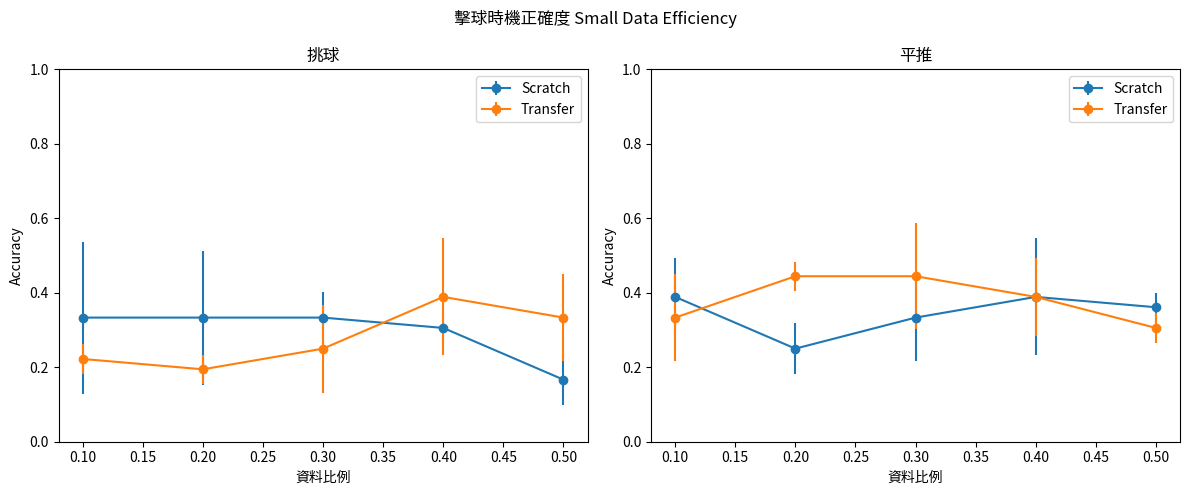

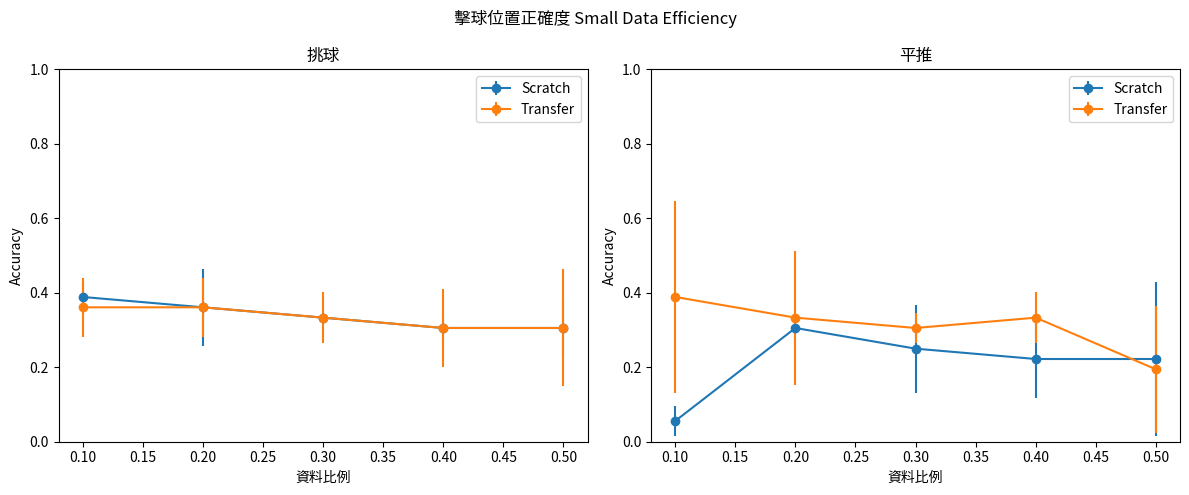

In [4]:
plt.rcParams["font.family"] = "Noto Sans CJK JP"
plt.rcParams["axes.unicode_minus"] = False


# ===== 讀取檔案（修正編碼問題）=====
def load_clean_csv(path):
    df = pd.read_csv(path, encoding="utf-8-sig")

    # 強制重命名欄位，避免亂碼
    df.columns = [
        "維度",
        "動作",
        "資料比例",
        "Scratch_mean",
        "Scratch_std",
        "Transfer_mean",
        "Transfer_std"
    ]

    # 把 10% 轉成 0.1
    df["資料比例"] = df["資料比例"].str.replace("%", "").astype(float) / 100.0

    return df


# ===== 畫單一維度圖 =====
def plot_small_data(df, title):

    df_挑 = df[df["動作"] == "挑球"]
    df_推 = df[df["動作"] == "平推"]

    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    for ax, sub_df, stroke in zip(
        axes,
        [df_挑, df_推],
        ["挑球", "平推"]
    ):

        ax.errorbar(
            sub_df["資料比例"],
            sub_df["Scratch_mean"],
            yerr=sub_df["Scratch_std"],
            marker="o",
            label="Scratch"
        )

        ax.errorbar(
            sub_df["資料比例"],
            sub_df["Transfer_mean"],
            yerr=sub_df["Transfer_std"],
            marker="o",
            label="Transfer"
        )

        ax.set_title(stroke)
        ax.set_xlabel("資料比例")
        ax.set_ylabel("Accuracy")
        ax.set_ylim(0,1)
        ax.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


# ===== 讀四個維度 =====
df_speed = load_clean_csv(
    "/home/sabrina/AI-Badminton-111/fine-tune/以拍為單位切/揮拍速度流暢度_small_data_results.csv"
)
df_wrist = load_clean_csv(
    "/home/sabrina/AI-Badminton-111/fine-tune/以拍為單位切/手腕轉動時機正確度_small_data_results.csv"
)

df_timing = load_clean_csv(
    "/home/sabrina/AI-Badminton-111/fine-tune/以拍為單位切/擊球時機正確度_small_data_results.csv"
)

df_position = load_clean_csv(
    "/home/sabrina/AI-Badminton-111/fine-tune/以拍為單位切/擊球位置正確度_small_data_results.csv"
)


# ===== 畫四張圖 =====
plot_small_data(df_speed, "揮拍速度流暢度 Small Data Efficiency")
plot_small_data(df_wrist, "手腕轉動時機正確度 Small Data Efficiency")
plot_small_data(df_timing, "擊球時機正確度 Small Data Efficiency")
plot_small_data(df_position, "擊球位置正確度 Small Data Efficiency")

## 以人為單位切:挑&推的揮拍軌跡正確度

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 讀檔
path = "/home/sabrina/AI-Badminton-111/fine-tune/以人為單位切/揮拍軌跡正確度_以人為單位_finetune_results.csv"
df = pd.read_csv(path)

display(df)
print(df.columns)

,維度,動作,資料比例,Scratch_mean,Scratch_std,Transfer_mean,Transfer_std,測試方式
0,揮拍軌跡正確度,挑球,10%,0.388889,0.141639,0.277778,0.039284,subject-based split
1,揮拍軌跡正確度,挑球,20%,0.305556,0.141639,0.333333,0.180021,subject-based split
2,揮拍軌跡正確度,挑球,30%,0.361111,0.078567,0.277778,0.039284,subject-based split
3,揮拍軌跡正確度,挑球,40%,0.500000,0.068041,0.222222,0.078567,subject-based split
4,揮拍軌跡正確度,挑球,50%,0.388889,0.171234,0.305556,0.141639,subject-based split
5,揮拍軌跡正確度,平推,10%,0.166667,0.117851,0.416667,0.136083,subject-based split
6,揮拍軌跡正確度,平推,20%,0.555556,0.103935,0.333333,0.180021,subject-based split
7,揮拍軌跡正確度,平推,30%,0.527778,0.257601,0.416667,0.117851,subject-based split
8,揮拍軌跡正確度,平推,40%,0.611111,0.103935,0.250000,0.204124,subject-based split
9,揮拍軌跡正確度,平推,50%,0.638889,0.157135,0.250000,0.136083,subject-based split


Index(['維度', '動作', '資料比例', 'Scratch_mean', 'Scratch_std', 'Transfer_mean',
       'Transfer_std', '測試方式'],
      dtype='object')


In [6]:
# 處理資料比例：'10%' -> 10
df["資料比例_num"] = df["資料比例"].str.replace("%", "").astype(int)

# 設定中文字型
plt.rcParams["font.family"] = "Noto Sans CJK JP"
plt.rcParams["axes.unicode_minus"] = False

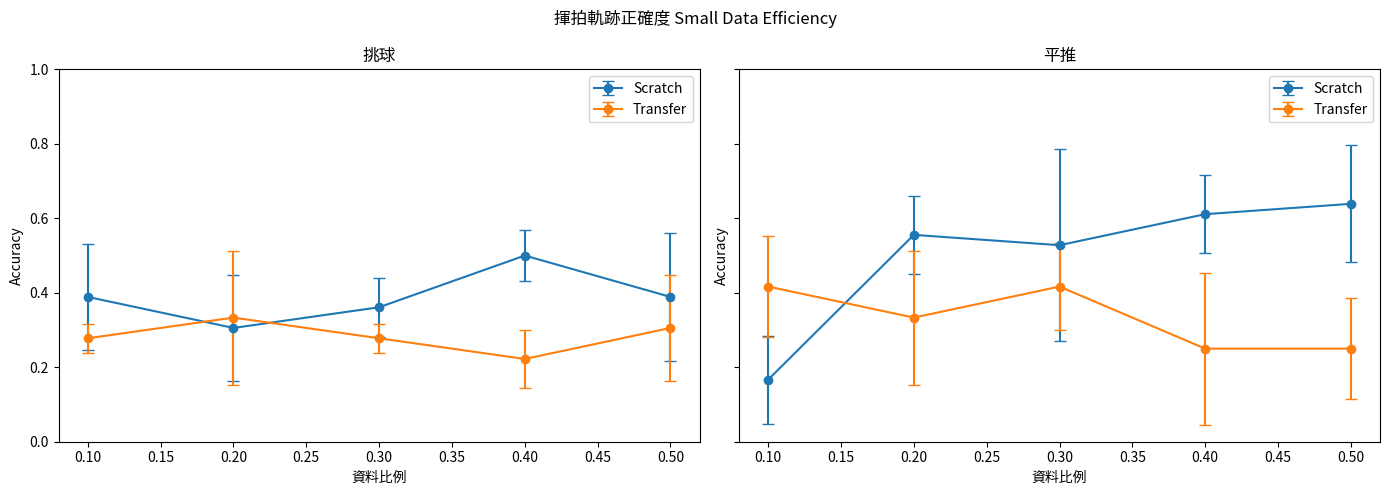

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

path = "/home/sabrina/AI-Badminton-111/fine-tune/以人為單位切/揮拍軌跡正確度_以人為單位_finetune_results.csv"
df = pd.read_csv(path)

# 10% -> 0.10
df["資料比例_num"] = df["資料比例"].str.replace("%", "").astype(float) / 100

plt.rcParams["font.family"] = "Noto Sans CJK JP"
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, action in zip(axes, ["挑球", "平推"]):
    sub = df[df["動作"] == action].sort_values("資料比例_num")

    ax.errorbar(
        sub["資料比例_num"],
        sub["Scratch_mean"],
        yerr=sub["Scratch_std"],
        marker="o",
        capsize=4,
        label="Scratch"
    )

    ax.errorbar(
        sub["資料比例_num"],
        sub["Transfer_mean"],
        yerr=sub["Transfer_std"],
        marker="o",
        capsize=4,
        label="Transfer"
    )

    ax.set_title(action)
    ax.set_xlabel("資料比例")
    ax.set_ylim(0, 1)
    ax.grid(False)
    ax.legend()

axes[0].set_ylabel("Accuracy")
axes[1].set_ylabel("Accuracy")

fig.suptitle("揮拍軌跡正確度 Small Data Efficiency")
plt.tight_layout()
plt.show()

## 以人為單位來切的揮拍速度流暢度，手腕轉動時機正確度,擊球時機正確度,擊球位置正確度

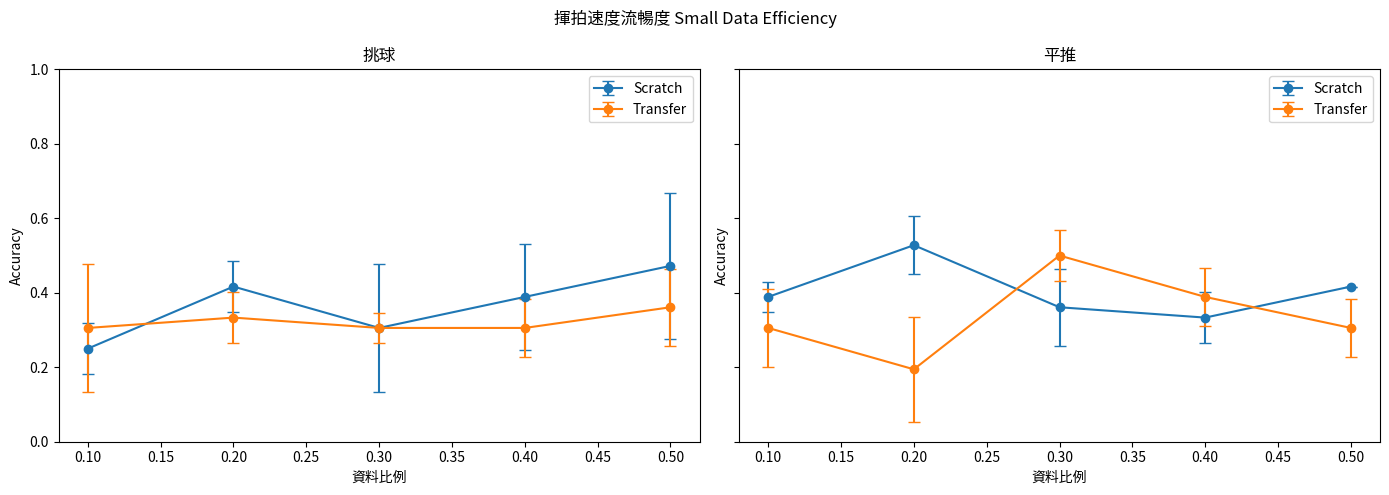

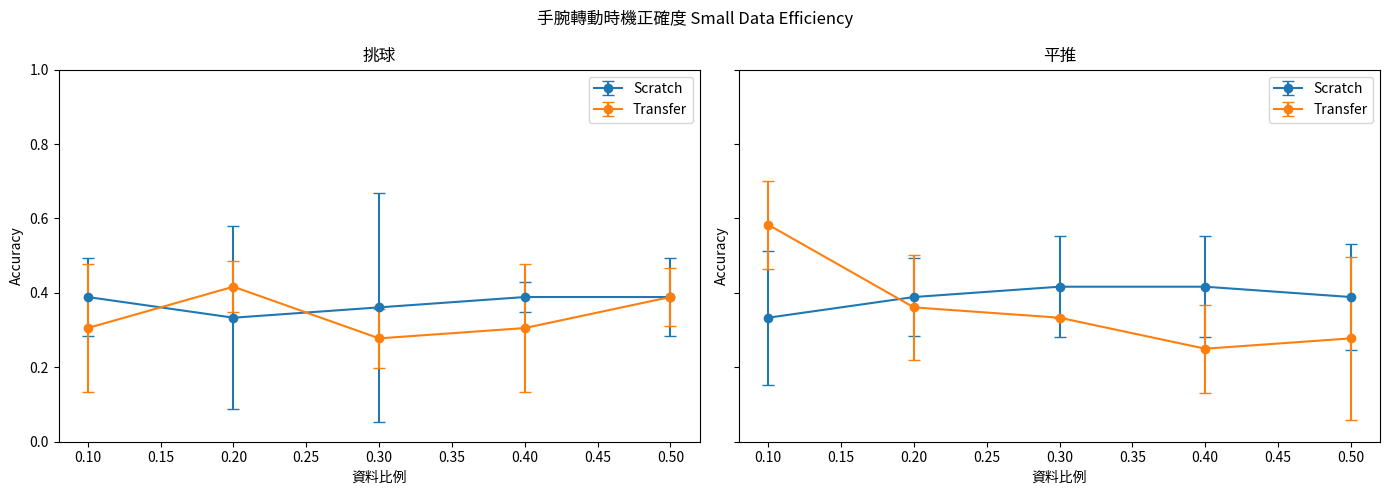

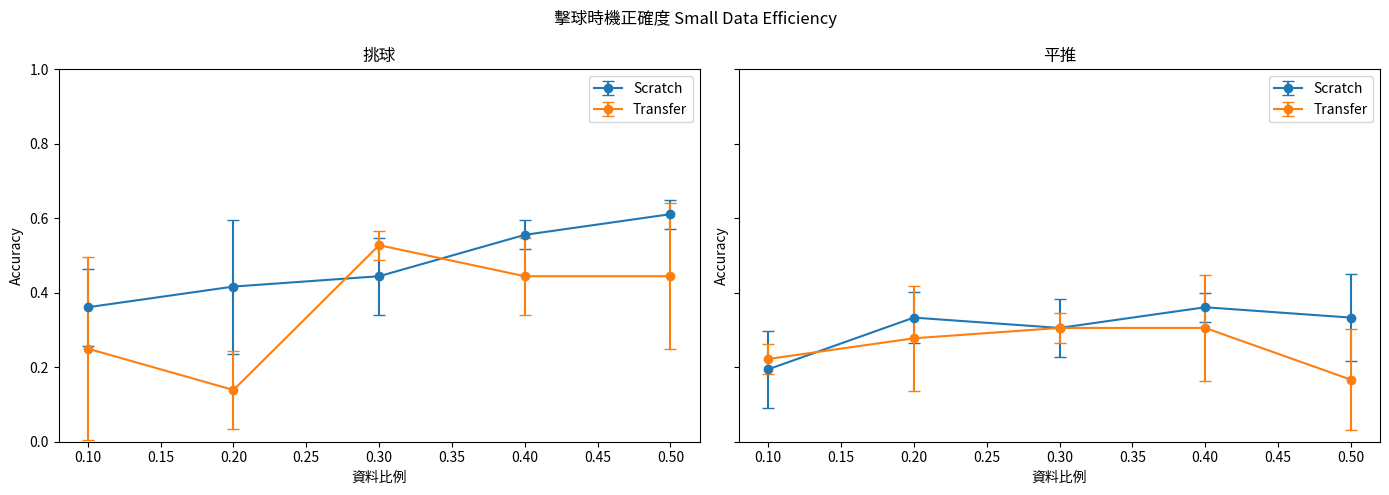

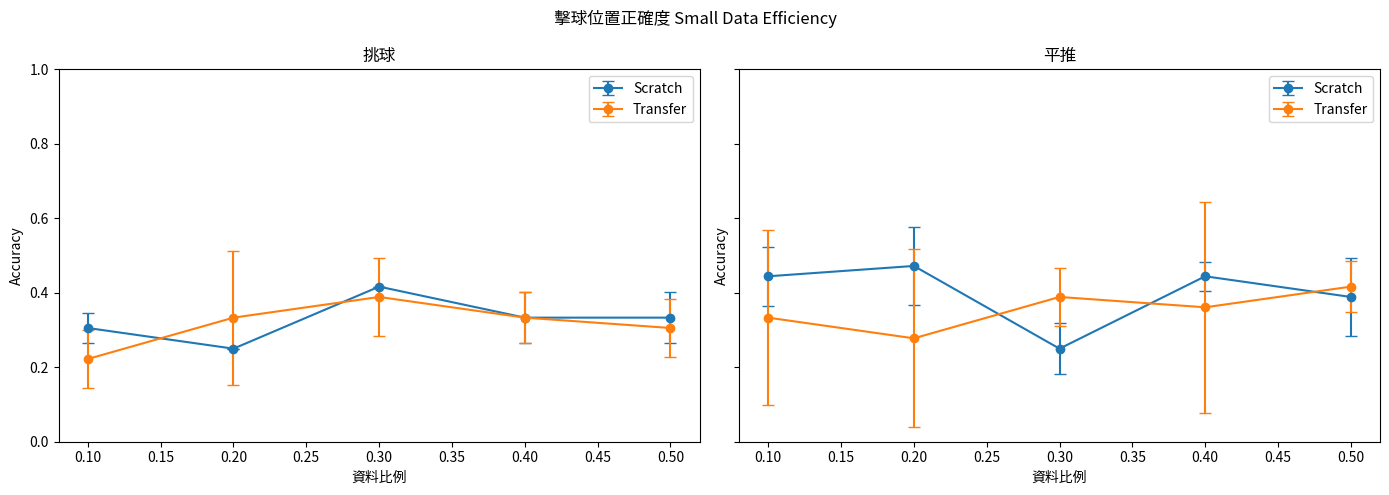

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

base_dir = "/home/sabrina/AI-Badminton-111/fine-tune/以人為單位切"

metric_names = [
    "揮拍速度流暢度",
    "手腕轉動時機正確度",
    "擊球時機正確度",
    "擊球位置正確度"
]

plt.rcParams["font.family"] = "Noto Sans CJK JP"
plt.rcParams["axes.unicode_minus"] = False

for metric_name in metric_names:
    path = f"{base_dir}/{metric_name}_以人為單位_finetune_results.csv"
    df = pd.read_csv(path)

    # 10% -> 0.10
    df["資料比例_num"] = df["資料比例"].str.replace("%", "").astype(float) / 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, action in zip(axes, ["挑球", "平推"]):
        sub = df[df["動作"] == action].sort_values("資料比例_num")

        ax.errorbar(
            sub["資料比例_num"],
            sub["Scratch_mean"],
            yerr=sub["Scratch_std"],
            marker="o",
            capsize=4,
            label="Scratch"
        )

        ax.errorbar(
            sub["資料比例_num"],
            sub["Transfer_mean"],
            yerr=sub["Transfer_std"],
            marker="o",
            capsize=4,
            label="Transfer"
        )

        ax.set_title(action)
        ax.set_xlabel("資料比例")
        ax.set_ylim(0, 1)
        ax.legend()

    axes[0].set_ylabel("Accuracy")
    axes[1].set_ylabel("Accuracy")

    fig.suptitle(f"{metric_name} Small Data Efficiency")
    plt.tight_layout()
    plt.show()

## 前面怪怪

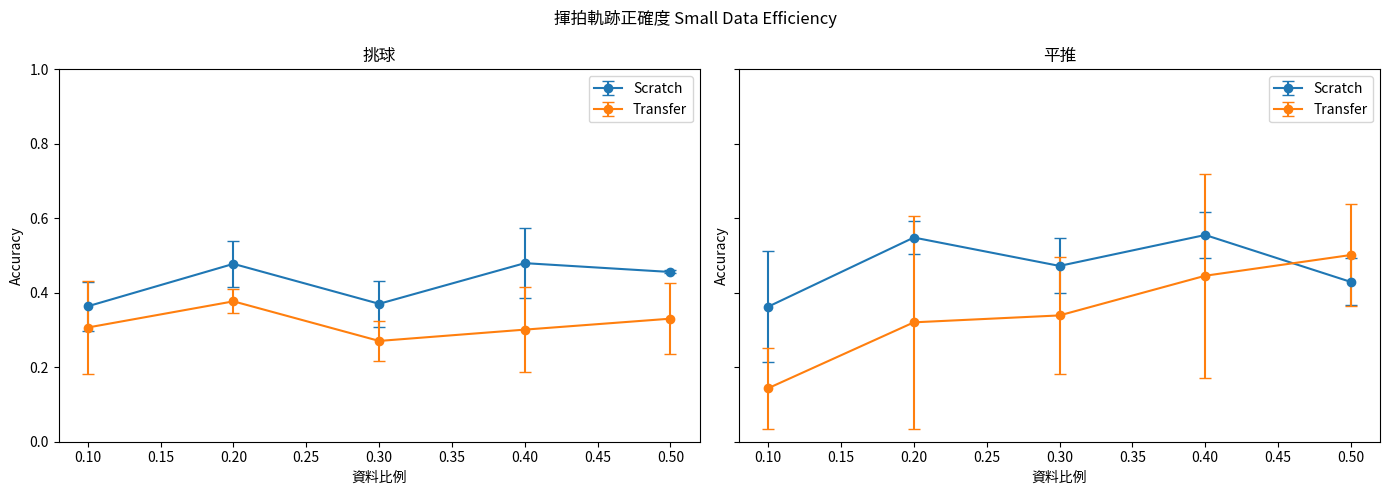

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

path = "/home/sabrina/AI-Badminton-111/fine-tune/人為單位_新版/揮拍軌跡正確度_以人為單位(新)_finetune_.csv"

df = pd.read_csv(path)

df["資料比例_num"] = df["資料比例"].str.replace("%", "").astype(float) / 100

plt.rcParams["font.family"] = "Noto Sans CJK JP"
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, action in zip(axes, ["挑球", "平推"]):
    sub = df[df["動作"] == action].sort_values("資料比例_num")

    ax.errorbar(
        sub["資料比例_num"],
        sub["Scratch_mean"],
        yerr=sub["Scratch_std"],
        marker="o",
        capsize=4,
        label="Scratch"
    )

    ax.errorbar(
        sub["資料比例_num"],
        sub["Transfer_mean"],
        yerr=sub["Transfer_std"],
        marker="o",
        capsize=4,
        label="Transfer"
    )

    ax.set_title(action)
    ax.set_xlabel("資料比例")
    ax.set_ylim(0, 1)
    ax.legend()

axes[0].set_ylabel("Accuracy")
axes[1].set_ylabel("Accuracy")

fig.suptitle("揮拍軌跡正確度 Small Data Efficiency")
plt.tight_layout()
plt.show()

## 新的fine tune (其他四個維度)

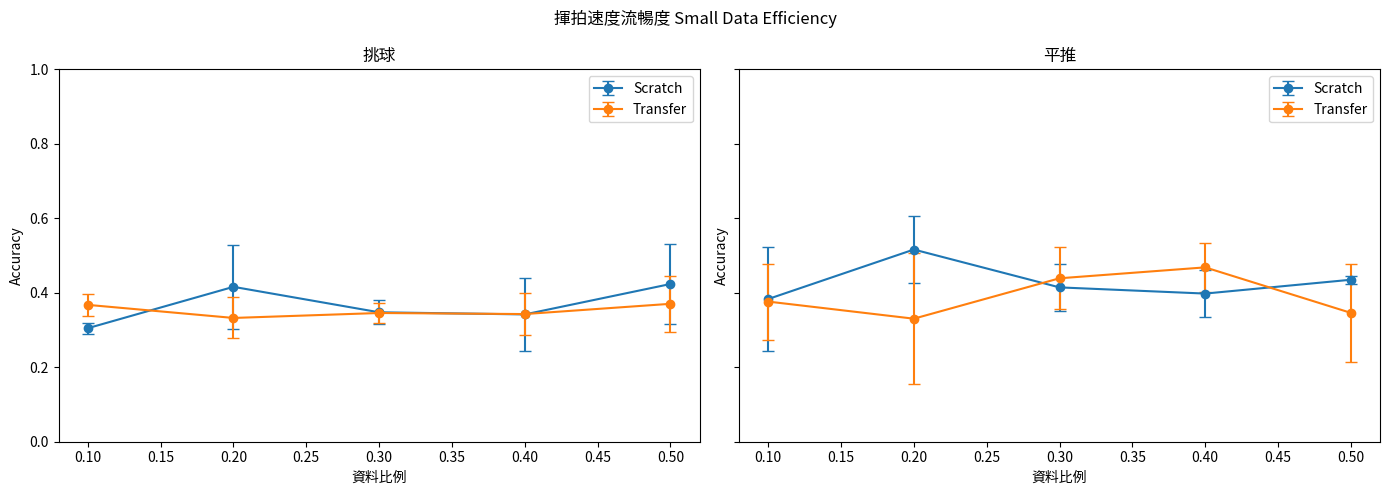

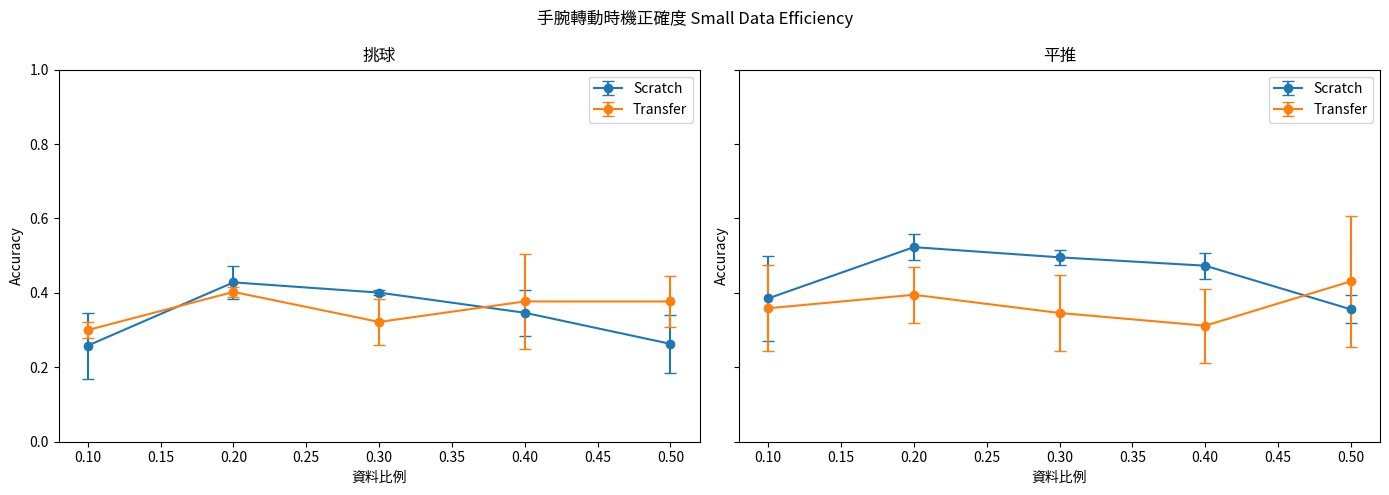

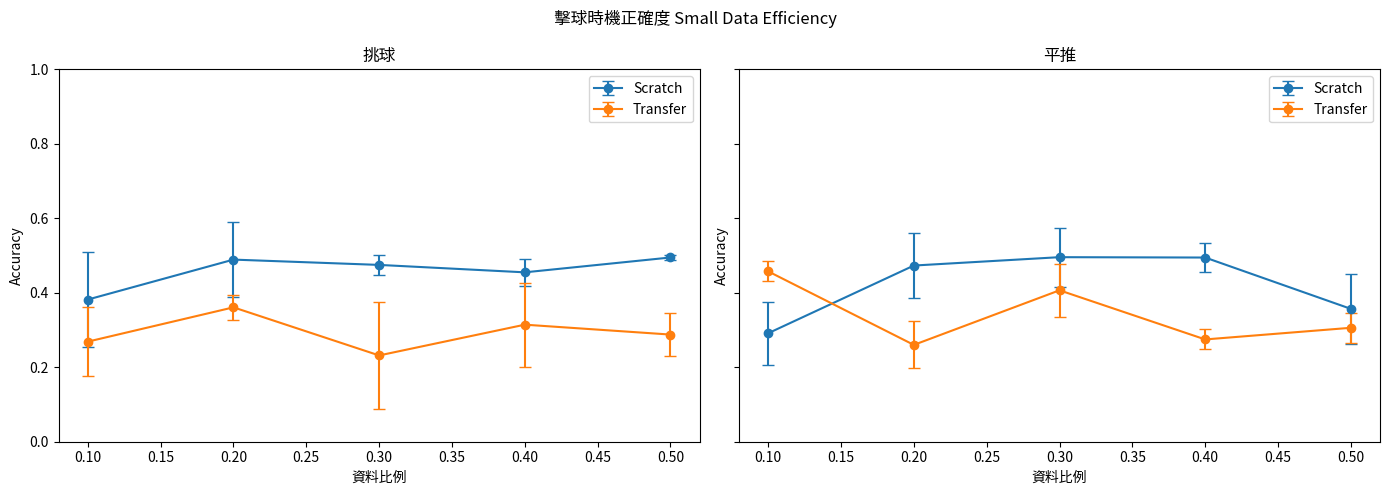

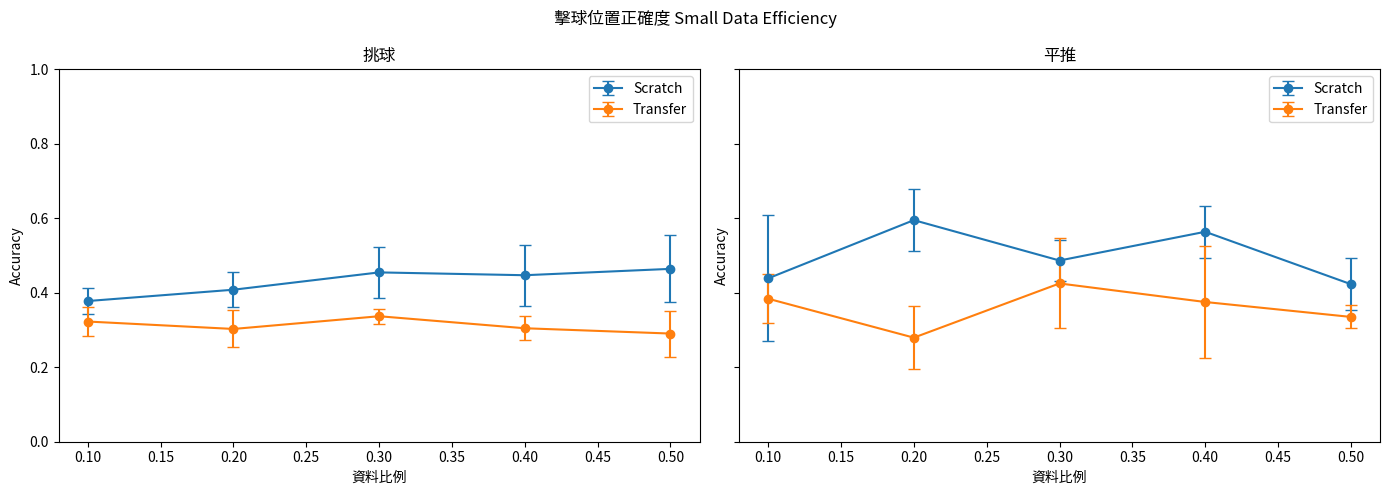

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

base_dir = "/home/sabrina/AI-Badminton-111/fine-tune/人為單位_新版"

metric_names = [
    "揮拍速度流暢度",
    "手腕轉動時機正確度",
    "擊球時機正確度",
    "擊球位置正確度"
]

plt.rcParams["font.family"] = "Noto Sans CJK JP"
plt.rcParams["axes.unicode_minus"] = False

for metric_name in metric_names:
    path = f"{base_dir}/{metric_name}_以人為單位(新)_finetune_.csv"
    df = pd.read_csv(path)

    df["資料比例_num"] = df["資料比例"].str.replace("%", "").astype(float) / 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, action in zip(axes, ["挑球", "平推"]):
        sub = df[df["動作"] == action].sort_values("資料比例_num")

        ax.errorbar(
            sub["資料比例_num"],
            sub["Scratch_mean"],
            yerr=sub["Scratch_std"],
            marker="o",
            capsize=4,
            label="Scratch"
        )

        ax.errorbar(
            sub["資料比例_num"],
            sub["Transfer_mean"],
            yerr=sub["Transfer_std"],
            marker="o",
            capsize=4,
            label="Transfer"
        )

        ax.set_title(action)
        ax.set_xlabel("資料比例")
        ax.set_ylim(0, 1)
        ax.legend()

    axes[0].set_ylabel("Accuracy")
    axes[1].set_ylabel("Accuracy")

    fig.suptitle(f"{metric_name} Small Data Efficiency")
    plt.tight_layout()
    plt.show()

In [3]:
import os

base_dir = "/home/sabrina/AI-Badminton-111/fine-tune/人為單位_新版"

for f in os.listdir(base_dir):
    print(f)

揮拍速度流暢度_以人為單位(新)_finetune_.csv
手腕轉動時機正確度_以人為單位(新)_finetune_.csv
擊球位置正確度_以人為單位(新)_finetune_.csv
揮拍軌跡正確度_以人為單位(新)_finetune_.csv
擊球時機正確度_以人為單位(新)_finetune_.csv
